In [434]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from math import log
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [435]:
# =============================================================================
# SECTION 1: DATA LOADING & EXPLORATION
# =============================================================================

def load_and_explore_data(file_path):
    """Load dataset and show basic information"""
    print("=" * 60)
    print("SECTION 1: DATA LOADING & EXPLORATION")
    print("=" * 60)

    # Load data
    df = pd.read_excel(file_path)
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

    # Target variables
    target_cols = ['PD_F', 'PD_F_TMP', 'MAN_UI', 'QUAL', 'SPM']

    print("\nChecking for missing values:")
    for col in target_cols + ['Review']:
        missing_count = df[col].isna().sum()
        print(f"{col}: {missing_count} missing values")

    # Handle missing values in target variables
    print("\nHandling missing values in target variables...")
    original_shape = df.shape[0]

    # Remove rows with any missing target values
    df = df.dropna(subset=target_cols)

    print(f"Removed {original_shape - df.shape[0]} rows with missing target values")
    print(f"Remaining dataset shape: {df.shape}")

    # Handle missing reviews
    if df['Review'].isna().sum() > 0:
        print(f"Filling {df['Review'].isna().sum()} missing reviews with empty string")
        df['Review'] = df['Review'].fillna('')

    print("\nTarget Variable Distributions:")
    for col in target_cols:
        print(f"{col}: {df[col].value_counts().to_dict()}")

    print("\nSample Reviews:")
    for i, review in enumerate(df['Review'].head(3)):
        print(f"Review {i+1}: {str(review)[:100]}...")

    return df, target_cols

In [436]:
# =============================================================================
# SECTION 2: MINIMAL TEXT CLEANING
# =============================================================================

def minimal_text_cleaning(text):
    """Minimal cleaning - handle spaces, preserve punctuation"""
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Remove excessive whitespace but preserve single spaces
    text = re.sub(r'\s+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    # Preserve all punctuation - no removal

    return text

def clean_reviews(df):
    """Apply minimal cleaning to reviews"""
    print("=" * 60)
    print("SECTION 2: MINIMAL TEXT CLEANING")
    print("=" * 60)

    print("Before cleaning:")
    print(f"Sample: {df['Review'].iloc[0][:100]}...")

    df['Review_Clean'] = df['Review'].apply(minimal_text_cleaning)

    print("\nAfter cleaning:")
    print(f"Sample: {df['Review_Clean'].iloc[0][:100]}...")

    print(f"\nCleaning stats:")
    print(f"Empty reviews after cleaning: {(df['Review_Clean'] == '').sum()}")
    print(f"Average review length: {df['Review_Clean'].str.len().mean():.1f} characters")

    return df

In [437]:
# =============================================================================
# SECTION 3: TEMPLATE DETECTION FEATURES
# =============================================================================

def extract_template_features(text):
    """Extract comprehensive features including template detection and spam detection"""
    features = {}

    if not text or pd.isna(text):
        text = ""

    text_clean = str(text).strip()
    words = text_clean.split() if text_clean else []

    # =============================================================================
    # BASIC TEXT FEATURES
    # =============================================================================
    features['char_length'] = len(text_clean)
    features['word_count'] = len(words)
    features['sentence_count'] = len(re.split(r'[.!?]+', text_clean)) - 1
    features['avg_word_length'] = np.mean([len(word) for word in words]) if words else 0
    features['avg_sentence_length'] = len(words) / max(1, features['sentence_count'])

    # Character type ratios
    if text_clean:
        features['alpha_ratio'] = sum(c.isalpha() for c in text_clean) / len(text_clean)
        features['digit_ratio'] = sum(c.isdigit() for c in text_clean) / len(text_clean)
        features['space_ratio'] = sum(c.isspace() for c in text_clean) / len(text_clean)
        features['punct_ratio'] = sum(not c.isalnum() and not c.isspace() for c in text_clean) / len(text_clean)
        features['upper_ratio'] = sum(c.isupper() for c in text_clean) / len(text_clean)
    else:
        features['alpha_ratio'] = features['digit_ratio'] = features['space_ratio'] = 0
        features['punct_ratio'] = features['upper_ratio'] = 0

    # =============================================================================
    # SPAM DETECTION FEATURES
    # =============================================================================

    # 1. Repetitive Text Detection
    if words:
        word_freq = Counter(words)
        most_common_freq = word_freq.most_common(1)[0][1]
        features['word_repetition_ratio'] = most_common_freq / len(words)
        features['unique_word_ratio'] = len(set(words)) / len(words)
    else:
        features['word_repetition_ratio'] = 0
        features['unique_word_ratio'] = 0

    # 2. Character-level repetition patterns
    if text_clean:
        char_freq = Counter(text_clean.lower())
        most_common_char_freq = char_freq.most_common(1)[0][1]
        features['char_repetition_ratio'] = most_common_char_freq / len(text_clean)

        # Consecutive character repetition
        consecutive_chars = re.findall(r'(.)\1{2,}', text_clean.lower())  # 3+ same chars in a row
        features['consecutive_char_groups'] = len(consecutive_chars)
        features['max_consecutive_chars'] = max([len(match) + 1 for match in consecutive_chars], default=0)
    else:
        features['char_repetition_ratio'] = 0
        features['consecutive_char_groups'] = 0
        features['max_consecutive_chars'] = 0

    # 3. Random/Nonsensical patterns
    # Vowel to consonant ratio (natural language has patterns)
    vowels = 'aeiouAEIOU'
    if text_clean:
        vowel_count = sum(1 for c in text_clean if c in vowels)
        consonant_count = sum(1 for c in text_clean if c.isalpha() and c not in vowels)
        features['vowel_consonant_ratio'] = vowel_count / max(1, consonant_count)
    else:
        features['vowel_consonant_ratio'] = 0

    # Character sequence patterns (randomness indicators)
    features['has_random_sequences'] = bool(re.search(r'[a-z]{10,}', text_clean.lower()))
    features['has_number_sequences'] = bool(re.search(r'\d{5,}', text_clean))

    # 4. Excessive punctuation patterns
    features['dot_count'] = text_clean.count('.')
    features['comma_count'] = text_clean.count(',')
    features['colon_count'] = text_clean.count(':')
    features['exclamation_count'] = text_clean.count('!')
    features['question_count'] = text_clean.count('?')
    features['total_punct_count'] = sum(not c.isalnum() and not c.isspace() for c in text_clean)

    # Specific punctuation sequence patterns
    features['dot_comma_count'] = text_clean.count('.,')
    features['comma_space_count'] = text_clean.count(', ')
    features['colon_space_count'] = text_clean.count(': ')

    # Excessive punctuation sequences
    features['excessive_dots'] = len(re.findall(r'\.{3,}', text_clean))
    features['excessive_commas'] = len(re.findall(r',{2,}', text_clean))
    features['excessive_colons'] = len(re.findall(r':{2,}', text_clean))
    features['excessive_exclamations'] = len(re.findall(r'!{2,}', text_clean))
    features['punct_density'] = features['total_punct_count'] / max(1, len(text_clean))

    # 5. Very short/minimal content
    features['is_very_short'] = len(text_clean.strip()) <= 3
    features['is_single_word'] = len(words) == 1
    features['is_single_char'] = len(text_clean.strip()) == 1

    # 6. Extended character patterns (like "goooooood")
    extended_patterns = re.findall(r'(\w)\1{3,}', text_clean.lower())
    features['extended_char_patterns'] = len(extended_patterns)
    features['has_extended_chars'] = len(extended_patterns) > 0

    # 7. Keyboard mashing detection
    # Common keyboard sequences
    keyboard_patterns = ['qwerty', 'asdf', 'zxcv', '123', 'abc', 'qaz', 'wsx']
    features['keyboard_mashing'] = any(pattern in text_clean.lower() for pattern in keyboard_patterns)

    # Random alternating pattern
    features['alternating_pattern'] = bool(re.search(r'([a-z])\1*([a-z])\2*\1', text_clean.lower()))

    # Enhanced nonsense detection
    random_sequences = re.findall(r'\b[a-z]{8,}\b', text_clean.lower())
    features['random_word_count'] = len(random_sequences)
    features['has_random_words'] = len(random_sequences) > 0

    repetitive_patterns = re.findall(r'\b(\w{2,3})\1{2,}\b', text_clean.lower())
    features['repetitive_nonsense'] = len(repetitive_patterns)
    features['has_repetitive_nonsense'] = len(repetitive_patterns) > 0

    # Additional gibberish patterns for attribute values
    weird_sequences = re.findall(r'\b[a-z]*[0-9]+[a-z]*\b', text_clean.lower())  # Mixed letters/numbers
    consonant_heavy = re.findall(r'\b[bcdfghjklmnpqrstvwxyz]{5,}\b', text_clean.lower())  # Too many consonants
    features['weird_sequences'] = len(weird_sequences)
    features['consonant_heavy_words'] = len(consonant_heavy)

    # =============================================================================
    # TEMPLATE DETECTION FEATURES (from previous implementation)
    # =============================================================================

    # Punctuation & Formatting Patterns - Enhanced colon detection
    colon_pairs = len(re.findall(r'\b\w+:\s*\w+', text_clean))
    features['colon_pairs'] = colon_pairs
    features['colon_density'] = colon_pairs / max(1, len(words))
    features['attribute_pattern'] = bool(re.search(r'(\w+:\s*\w+.*){2,}', text_clean))

    # NEW: Single attribute detection (attribute + colon pattern)
    single_attributes = re.findall(r'\b\w+:', text_clean)
    features['single_attribute_count'] = len(single_attributes)
    features['single_attribute_density'] = len(single_attributes) / max(1, len(words))
    features['has_single_attributes'] = len(single_attributes) > 0

    # Extract unique attribute words for analysis
    attribute_words = [attr.replace(':', '') for attr in single_attributes]
    features['unique_attributes'] = len(set(attribute_words))

    # Common template attribute words
    common_attributes = [
        'design', 'quality', 'price', 'material', 'size', 'color', 'weight',
        'sound', 'battery', 'comfort', 'durability', 'packaging', 'delivery',
        'service', 'value', 'performance', 'rating', 'review', 'product',
        'portability', 'build', 'appearance', 'style', 'function', 'usability', 'reliability'
    ]

    template_attribute_matches = sum(1 for attr in attribute_words
                                   if attr.lower() in common_attributes)
    features['template_attribute_count'] = template_attribute_matches
    features['template_attribute_ratio'] = template_attribute_matches / max(1, len(attribute_words))

    # Separator consistency (moved to avoid duplication)
    features['semicolon_count'] = text_clean.count(';')

    # Lexical Repetition Patterns for templates
    value_words = ['good', 'great', 'perfect', 'excellent', 'amazing', 'nice', 'awesome', 'fantastic']
    value_word_count = sum(text_clean.lower().count(word) for word in value_words)
    features['value_word_count'] = value_word_count
    features['value_word_density'] = value_word_count / max(1, len(words))

    # Template phrases - Enhanced detection
    template_phrases = [
        'great value for money', 'perfect for', 'ideal for', 'highly recommend',
        'easy to use', 'good quality', 'fast delivery', 'excellent service',
        'worth the price', 'as expected', 'satisfied with', 'durable and long-lasting',
        'stylish design', 'comfortable to wear', 'perfect fit', 'great for everyday',
        'versatile and practical', 'good for the price', 'would recommend',
        'nice and comfortable', 'looks good', 'feels good'
    ]
    features['template_phrase_count'] = sum(1 for phrase in template_phrases if phrase in text_clean.lower())
    features['has_template_phrases'] = features['template_phrase_count'] > 0
    features['has_any_template_phrase'] = features['template_phrase_count'] > 0

    # Enhanced template phrase detection - partial matches
    template_keywords = [
        'durable', 'long-lasting', 'stylish', 'comfortable', 'perfect',
        'versatile', 'practical', 'recommend', 'excellent', 'amazing',
        'fantastic', 'great', 'nice', 'good quality', 'high quality'
    ]

    template_keyword_matches = sum(1 for keyword in template_keywords
                                 if keyword in text_clean.lower())
    features['template_keyword_count'] = template_keyword_matches
    features['template_keyword_density'] = template_keyword_matches / max(1, len(words))

    # MIXED PATTERN DETECTION - Template + Natural combination
    # Detect structured beginning + natural ending
    has_early_attributes = bool(re.search(r'^[^.!?]*\w+:\s*\w+', text_clean))
    has_natural_continuation = bool(re.search(r'[.!?]\s*[a-z]', text_clean))  # lowercase after punctuation
    features['mixed_structure_pattern'] = has_early_attributes and has_natural_continuation

    # Template-to-natural transition detection
    sentences_with_colons = [s for s in re.split(r'[.!?]+', text_clean) if ':' in s]
    sentences_without_colons = [s for s in re.split(r'[.!?]+', text_clean) if ':' not in s and s.strip()]

    features['structured_sentences'] = len(sentences_with_colons)
    features['natural_sentences'] = len(sentences_without_colons)
    features['structure_transition_ratio'] = len(sentences_with_colons) / max(1, len(sentences_without_colons))

    # Comma-separated template values after colons
    colon_segments = re.findall(r'\w+:\s*([^,.:!?]+)', text_clean)
    template_like_segments = 0
    for segment in colon_segments:
        segment_words = segment.strip().split()
        if len(segment_words) >= 2 and any(word.lower() in template_keywords for word in segment_words):
            template_like_segments += 1

    features['template_value_segments'] = template_like_segments
    features['template_value_ratio'] = template_like_segments / max(1, len(colon_segments))

    # Adjective diversity
    adjectives = value_words + ['nice', 'bad', 'terrible', 'okay', 'fine']
    text_adjectives = [word for word in words if word.lower() in adjectives]
    features['unique_adjectives'] = len(set(text_adjectives))
    features['adjective_diversity'] = features['unique_adjectives'] / max(1, len(text_adjectives))

    # Attribute + gibberish pattern detection (enhanced to handle spaces)
    # Pattern 1: "attribute:gibberish" (no space after colon)
    attribute_gibberish_nospace = re.findall(r'\b\w+:[a-z]{6,}', text_clean.lower())
    # Pattern 2: "attribute: gibberish" (space after colon)
    attribute_gibberish_space = re.findall(r'\b\w+:\s+[a-z]{6,}', text_clean.lower())
    # Pattern 3: "attribute:value gibberish" (value followed by gibberish)
    attribute_value_gibberish = re.findall(r'\b\w+:\s*\w+\s+[a-z]{6,}', text_clean.lower())

    total_gibberish_patterns = len(attribute_gibberish_nospace) + len(attribute_gibberish_space) + len(attribute_value_gibberish)
    features['attribute_gibberish_count'] = total_gibberish_patterns
    features['has_attribute_gibberish'] = total_gibberish_patterns > 0

    # Enhanced repeated values detection (handles both spaced and non-spaced)
    attribute_values_nospace = re.findall(r'\b\w+:([a-z]+)', text_clean.lower())
    attribute_values_space = re.findall(r'\b\w+:\s+([a-z]+)', text_clean.lower())
    all_attribute_values = attribute_values_nospace + attribute_values_space

    if all_attribute_values:
        value_freq = Counter(all_attribute_values)
        most_common_value_freq = value_freq.most_common(1)[0][1]
        features['repeated_value_ratio'] = most_common_value_freq / len(all_attribute_values)
        features['has_repeated_values'] = most_common_value_freq > 1

        # Check if most values are gibberish (6+ random chars)
        gibberish_values = sum(1 for val in all_attribute_values if len(val) >= 6 and val.isalpha())
        features['gibberish_value_ratio'] = gibberish_values / len(all_attribute_values)
        features['has_mostly_gibberish_values'] = features['gibberish_value_ratio'] > 0.5
    else:
        features['repeated_value_ratio'] = 0
        features['has_repeated_values'] = False
        features['gibberish_value_ratio'] = 0
        features['has_mostly_gibberish_values'] = False

    # =============================================================================
    # LANGUAGE AND STRUCTURE PATTERNS
    # =============================================================================

    # Mixed language detection (basic)
    features['has_mixed_language'] = bool(re.search(r'[^\x00-\x7F]', text_clean))  # Non-ASCII chars

    # Sentence structure
    complete_sentences = [s for s in re.split(r'[.!?]+', text_clean)
                         if s.strip() and re.search(r'\b(is|are|was|were|have|has|do|does|will|can|should|the|a|an)\b', s.lower())]
    features['complete_sentences'] = len(complete_sentences)
    features['fragment_ratio'] = 1 - (len(complete_sentences) / max(1, features['sentence_count']))

    # Grammatical patterns
    features['has_articles'] = bool(re.search(r'\b(the|a|an)\b', text_clean.lower()))
    features['has_pronouns'] = bool(re.search(r'\b(i|you|he|she|it|we|they|me|him|her|us|them)\b', text_clean.lower()))
    features['has_verbs'] = bool(re.search(r'\b(is|are|was|were|have|has|do|does|will|can|should|go|get|make|take)\b', text_clean.lower()))

    # =============================================================================
    # COMPREHENSIVE SPAM SCORING SYSTEM
    # =============================================================================

    spam_score = 0
    template_score = 0

    # === HIGH SPAM INDICATORS (0.4 each) ===

    # 1. Attribute gibberish patterns
    if features['has_attribute_gibberish']:
        spam_score += 0.4

    # 2. Mostly gibberish values in attributes
    if features['has_mostly_gibberish_values']:
        spam_score += 0.4

    # 3. Multiple random sequences OR weird patterns
    if features['random_word_count'] >= 2 or features['weird_sequences'] >= 2 or features['consonant_heavy_words'] >= 2:
        spam_score += 0.4

    # 4. Attribute + random word combination (strong spam indicator)
    if features['colon_pairs'] >= 2 and (features['random_word_count'] >= 1 or features['weird_sequences'] >= 1):
        spam_score += 0.4

    # === MEDIUM SPAM INDICATORS (0.3 each) ===

    # 4. Pure attribute spam (multiple attributes, no natural language)
    if (features['colon_pairs'] >= 3 and
        not features['has_articles'] and not features['has_pronouns'] and
        features['word_count'] <= features['colon_pairs'] * 2):
        spam_score += 0.3

    # 5. Repeated simple values across attributes
    if features['has_repeated_values'] and features['colon_pairs'] >= 2:
        spam_score += 0.3

    # 6. High template phrase density (multiple template phrases in short text)
    template_phrase_density = features['template_phrase_count'] / max(1, features['word_count'] / 10)
    if template_phrase_density > 1.5:  # More than 1.5 template phrases per 10 words
        spam_score += 0.3

    # === TEMPLATE INDICATORS (separate scoring) ===

    # 7. Multiple colon pairs
    if features['colon_pairs'] >= 3:
        template_score += 0.3
    elif features['colon_pairs'] >= 2:
        template_score += 0.2

    # 8. High template attribute ratio
    if features['template_attribute_ratio'] > 0.7:
        template_score += 0.3

    # 9. Multiple template phrases
    if features['template_phrase_count'] >= 3:
        template_score += 0.3
    elif features['template_phrase_count'] >= 2:
        template_score += 0.2

    # 10. High simple value word density
    simple_value_density = features['value_word_count'] / max(1, features['word_count'])
    if simple_value_density > 0.5:  # More than 50% simple value words
        template_score += 0.3
    elif simple_value_density > 0.3:
        template_score += 0.2

    # 11. Low adjective diversity with template patterns
    if (features['adjective_diversity'] < 0.5 and
        (features['colon_pairs'] > 0 or features['template_phrase_count'] > 0)):
        template_score += 0.2

    # === MIXED PATTERN DETECTION ===

    # 12. Template + attribute mixed patterns
    if features['colon_pairs'] >= 2 and features['template_phrase_count'] >= 1:
        mixed_boost = 0.3
        spam_score += mixed_boost
        template_score += mixed_boost

    # 13. Natural + spam mixed (unnatural insertion of structured content)
    # Only flag if it's clearly spam insertion, not natural mentions
    if (features['has_articles'] and features['has_pronouns'] and
        features['colon_pairs'] >= 2 and features['word_count'] > 8 and
        (features['random_word_count'] > 0 or not features['has_verbs'])):
        spam_score += 0.2  # Only if it has suspicious patterns

    # === LOW-LEVEL INDICATORS (0.1 each) ===

    # 14. Repetitive nonsense
    if features['has_repetitive_nonsense']:
        spam_score += 0.1

    # 15. Low unique word ratio
    if features['unique_word_ratio'] < 0.6:
        spam_score += 0.1

    # 16. Unnatural vowel/consonant ratio
    if features['vowel_consonant_ratio'] < 0.3 or features['vowel_consonant_ratio'] > 2.0:
        spam_score += 0.1

    # 17. High fragment ratio with structured content
    if features['fragment_ratio'] > 0.7 and features['colon_pairs'] > 0:
        spam_score += 0.1

    # === SPECIAL CASE DETECTION ===

    # 18. Short template spam (few words, all template-like)
    if (features['word_count'] <= 8 and
        (features['template_phrase_count'] >= 1 or simple_value_density > 0.4) and
        not features['has_pronouns']):
        template_score += 0.4

    # 19. Pure attribute list spam (no natural language at all)
    if (features['colon_pairs'] >= 2 and
        features['word_count'] <= features['colon_pairs'] * 2.5 and
        not features['has_articles'] and not features['has_pronouns'] and not features['has_verbs']):
        spam_score += 0.4

    # === FINAL SCORING ===

    # Take maximum of spam_score and template_score, but combine for mixed patterns
    final_spam_score = max(spam_score, template_score)

    # Bonus for clear spam patterns
    if spam_score > 0.5 and template_score > 0.3:
        final_spam_score = min(1.0, final_spam_score + 0.2)

    features['spam_probability_score'] = min(1.0, final_spam_score)
    features['template_probability_score'] = min(1.0, template_score)
    features['is_likely_spam'] = final_spam_score > 0.5
    features['is_likely_template'] = template_score > 0.5

    # Additional diagnostic features
    features['template_phrase_density'] = template_phrase_density
    features['simple_value_density'] = simple_value_density

    return features

def create_feature_matrix(df):
    """Create feature matrix from reviews"""
    print("=" * 60)
    print("SECTION 3: FEATURE ENGINEERING")
    print("=" * 60)

    print("Extracting template detection features...")

    # Extract template features
    template_features = []
    for review in df['Review_Clean']:
        features = extract_template_features(review)
        template_features.append(features)

    # Convert to DataFrame
    feature_df = pd.DataFrame(template_features)

    print(f"Template features shape: {feature_df.shape}")
    print(f"Template feature columns: {list(feature_df.columns)}")

    # Combine with TF-IDF features (limited vocab for performance)
    print("\nCreating TF-IDF features...")
    tfidf = TfidfVectorizer(
        max_features=1000,  # Limit features for large dataset
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 2),
        lowercase=True
    )

    tfidf_features = tfidf.fit_transform(df['Review_Clean'])
    tfidf_df = pd.DataFrame(tfidf_features.toarray(),
                           columns=[f'tfidf_{i}' for i in range(tfidf_features.shape[1])])

    print(f"TF-IDF features shape: {tfidf_df.shape}")

    # Combine all features
    final_features = pd.concat([feature_df, tfidf_df], axis=1)

    print(f"Final feature matrix shape: {final_features.shape}")

    return final_features, tfidf

In [438]:
# =============================================================================
# SECTION 4: MODEL TRAINING
# =============================================================================

def train_logistic_models(X, y_dict, target_cols):
    """Train separate logistic regression for each target"""
    print("=" * 60)
    print("SECTION 4: MODEL TRAINING")
    print("=" * 60)

    models = {}
    scalers = {}
    results = {}

    for target in target_cols:
        print(f"\nTraining model for {target}...")

        y = y_dict[target]

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train model
        model = LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight='balanced'  # Handle imbalanced data
        )

        model.fit(X_train_scaled, y_train)

        # Predictions
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

        # Store results
        models[target] = model
        scalers[target] = scaler
        results[target] = {
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'X_test': X_test_scaled
        }

        print(f"✓ {target} model trained")
        print(f"  Training samples: {len(y_train)}")
        print(f"  Test samples: {len(y_test)}")
        print(f"  Class distribution: {Counter(y_train)}")

    return models, scalers, results

In [439]:
# =============================================================================
# SECTION 5: MODEL EVALUATION
# =============================================================================

def evaluate_models(models, results, target_cols):
    """Evaluate all models and show performance metrics"""
    print("=" * 60)
    print("SECTION 5: MODEL EVALUATION")
    print("=" * 60)

    evaluation_summary = {}

    for target in target_cols:
        print(f"\n{'-'*40}")
        print(f"EVALUATION FOR {target}")
        print(f"{'-'*40}")

        y_test = results[target]['y_test']
        y_pred = results[target]['y_pred']
        y_pred_proba = results[target]['y_pred_proba']

        # Classification report
        print("Classification Report:")
        print(classification_report(y_test, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print(f"\nConfusion Matrix:")
        print(cm)

        # ROC AUC Score
        try:
            auc_score = roc_auc_score(y_test, y_pred_proba)
            print(f"ROC AUC Score: {auc_score:.4f}")
        except:
            auc_score = None
            print("ROC AUC Score: Cannot calculate (single class in test set)")

        # Store summary
        evaluation_summary[target] = {
            'confusion_matrix': cm,
            'auc_score': auc_score,
            'accuracy': (y_pred == y_test).mean()
        }

    return evaluation_summary

In [440]:
# =============================================================================
# SECTION 6: FEATURE IMPORTANCE ANALYSIS
# =============================================================================

def analyze_feature_importance(models, feature_names, target_cols, top_n=10):
    """Analyze and display feature importance for each model"""
    print("=" * 60)
    print("SECTION 6: FEATURE IMPORTANCE ANALYSIS")
    print("=" * 60)

    for target in target_cols:
        print(f"\n{'-'*40}")
        print(f"TOP {top_n} FEATURES FOR {target}")
        print(f"{'-'*40}")

        model = models[target]

        # Get feature coefficients
        feature_importance = pd.DataFrame({
            'feature': feature_names,
            'coefficient': model.coef_[0],
            'abs_coefficient': np.abs(model.coef_[0])
        })

        # Sort by absolute importance
        top_features = feature_importance.nlargest(top_n, 'abs_coefficient')

        for _, row in top_features.iterrows():
            direction = "+" if row['coefficient'] > 0 else "-"
            print(f"  {direction} {row['feature']:<25} {row['coefficient']:>8.4f}")

In [441]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve, f1_score, precision_score, recall_score
import matplotlib.gridspec as gridspec

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


def plot_comprehensive_performance_metrics(results, target_cols, figsize=(20, 12)):
    """Plot comprehensive performance metrics including precision, recall, F1-score, and accuracy"""
    n_targets = len(target_cols)

    # Calculate metrics for each target
    metrics_data = []
    for target in target_cols:
        y_test = results[target]['y_test']
        y_pred = results[target]['y_pred']
        y_pred_proba = results[target]['y_pred_proba']

        # Calculate metrics
        accuracy = (y_pred == y_test).mean()
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        try:
            auc_score = roc_auc_score(y_test, y_pred_proba)
        except:
            auc_score = 0

        metrics_data.append({
            'Target': target,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'AUC': auc_score
        })

    df_metrics = pd.DataFrame(metrics_data)

    # Create comprehensive performance visualization
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

    # 1. Overall Performance Heatmap
    ax1 = fig.add_subplot(gs[0, :])
    metrics_matrix = df_metrics.set_index('Target')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']]
    sns.heatmap(metrics_matrix.T, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax1, cbar_kws={'label': 'Score'})
    ax1.set_title('Performance Metrics Heatmap', fontsize=16, pad=20)
    ax1.set_xlabel('Target Variables', fontsize=12)
    ax1.set_ylabel('Metrics', fontsize=12)

    # 2. Accuracy Comparison
    ax2 = fig.add_subplot(gs[1, 0])
    bars = ax2.bar(df_metrics['Target'], df_metrics['Accuracy'],
                   color='skyblue', edgecolor='navy', alpha=0.7)
    ax2.set_title('Accuracy by Target', fontsize=14)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_ylim([0, 1])
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # 3. Precision Comparison
    ax3 = fig.add_subplot(gs[1, 1])
    bars = ax3.bar(df_metrics['Target'], df_metrics['Precision'],
                   color='lightgreen', edgecolor='darkgreen', alpha=0.7)
    ax3.set_title('Precision by Target', fontsize=14)
    ax3.set_ylabel('Precision', fontsize=12)
    ax3.set_ylim([0, 1])
    ax3.grid(True, alpha=0.3, axis='y')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # 4. Recall Comparison
    ax4 = fig.add_subplot(gs[1, 2])
    bars = ax4.bar(df_metrics['Target'], df_metrics['Recall'],
                   color='orange', edgecolor='darkorange', alpha=0.7)
    ax4.set_title('Recall by Target', fontsize=14)
    ax4.set_ylabel('Recall', fontsize=12)
    ax4.set_ylim([0, 1])
    ax4.grid(True, alpha=0.3, axis='y')
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # 5. F1-Score Comparison
    ax5 = fig.add_subplot(gs[2, 0])
    bars = ax5.bar(df_metrics['Target'], df_metrics['F1-Score'],
                   color='purple', edgecolor='darkviolet', alpha=0.7)
    ax5.set_title('F1-Score by Target', fontsize=14)
    ax5.set_ylabel('F1-Score', fontsize=12)
    ax5.set_ylim([0, 1])
    ax5.grid(True, alpha=0.3, axis='y')
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # 6. AUC Comparison
    ax6 = fig.add_subplot(gs[2, 1])
    bars = ax6.bar(df_metrics['Target'], df_metrics['AUC'],
                   color='crimson', edgecolor='darkred', alpha=0.7)
    ax6.set_title('AUC Score by Target', fontsize=14)
    ax6.set_ylabel('AUC Score', fontsize=12)
    ax6.set_ylim([0, 1])
    ax6.grid(True, alpha=0.3, axis='y')
    plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # 7. Overall Performance Radar Chart
    ax7 = fig.add_subplot(gs[2, 2], projection='polar')

    # Calculate average metrics across all targets
    avg_metrics = df_metrics[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']].mean()

    # Radar chart
    angles = np.linspace(0, 2 * np.pi, len(avg_metrics), endpoint=False)
    values = avg_metrics.values

    # Close the plot
    angles = np.concatenate((angles, [angles[0]]))
    values = np.concatenate((values, [values[0]]))

    ax7.plot(angles, values, 'o-', linewidth=2, label='Average Performance')
    ax7.fill(angles, values, alpha=0.25)
    ax7.set_xticks(angles[:-1])
    ax7.set_xticklabels(avg_metrics.index)
    ax7.set_ylim(0, 1)
    ax7.set_title('Average Performance Radar', fontsize=14, pad=20)
    ax7.grid(True)

    plt.suptitle('Comprehensive Performance Metrics Dashboard', fontsize=18, y=0.98)
    plt.tight_layout()
    plt.show()

    return df_metrics


def plot_detailed_confusion_matrices_with_metrics(results, target_cols, figsize=(18, 12)):
    """Enhanced confusion matrices with detailed metrics"""
    n_targets = len(target_cols)
    n_cols = 3
    n_rows = (n_targets + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.suptitle('Detailed Confusion Matrices with Performance Metrics', fontsize=16, y=1.02)

    # Flatten axes for easier iteration
    if n_targets == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, target in enumerate(target_cols):
        ax = axes[idx]

        y_test = results[target]['y_test']
        y_pred = results[target]['y_pred']

        # Calculate confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        # Calculate metrics
        accuracy = (y_pred == y_test).mean()
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # Plot confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    cbar=True, square=True, ax=ax,
                    xticklabels=['Class 0', 'Class 1'],
                    yticklabels=['Class 0', 'Class 1'])

        ax.set_title(f'{target}', fontsize=14, pad=10)
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)

        # Add comprehensive metrics text
        metrics_text = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}'
        ax.text(0.5, -0.25, metrics_text, transform=ax.transAxes,
                ha='center', va='top', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

    # Hide extra subplots if any
    for idx in range(n_targets, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()


def plot_precision_recall_curves(results, target_cols, figsize=(12, 8)):
    """Plot precision-recall curves for all targets"""
    fig, ax = plt.subplots(figsize=figsize)

    colors = plt.cm.rainbow(np.linspace(0, 1, len(target_cols)))

    for idx, (target, color) in enumerate(zip(target_cols, colors)):
        y_test = results[target]['y_test']
        y_pred_proba = results[target]['y_pred_proba']

        # Calculate precision-recall curve
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        avg_precision = np.trapz(precision, recall)

        # Plot precision-recall curve
        ax.plot(recall, precision, color=color, lw=2,
                label=f'{target} (AP = {avg_precision:.3f})')

    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Precision-Recall Curves for All Target Variables', fontsize=14, pad=20)
    ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()


def plot_model_comparison_summary(results, target_cols, figsize=(15, 10)):
    """Create a comprehensive model comparison summary"""
    # Calculate all metrics
    summary_data = []
    for target in target_cols:
        y_test = results[target]['y_test']
        y_pred = results[target]['y_pred']
        y_pred_proba = results[target]['y_pred_proba']

        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, len(y_test))

        # Calculate detailed metrics
        accuracy = (y_pred == y_test).mean()
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        try:
            auc_score = roc_auc_score(y_test, y_pred_proba)
        except:
            auc_score = 0

        summary_data.append({
            'Target': target,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'F1-Score': f1,
            'AUC': auc_score,
            'True Positives': tp,
            'True Negatives': tn,
            'False Positives': fp,
            'False Negatives': fn
        })

    df_summary = pd.DataFrame(summary_data)

    # Create figure with subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('Model Performance Comparison Summary', fontsize=16, y=1.02)

    # 1. Performance metrics comparison
    metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    x = np.arange(len(target_cols))
    width = 0.15

    for i, metric in enumerate(metrics_cols):
        ax1.bar(x + i*width, df_summary[metric], width,
                label=metric, alpha=0.8)

    ax1.set_xlabel('Target Variables')
    ax1.set_ylabel('Score')
    ax1.set_title('Performance Metrics Comparison')
    ax1.set_xticks(x + width * 2)
    ax1.set_xticklabels(target_cols, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    # 2. Confusion matrix components
    confusion_metrics = ['True Positives', 'True Negatives', 'False Positives', 'False Negatives']
    bottom = np.zeros(len(target_cols))

    colors = ['green', 'blue', 'orange', 'red']
    for i, metric in enumerate(confusion_metrics):
        ax2.bar(target_cols, df_summary[metric], bottom=bottom,
                label=metric, color=colors[i], alpha=0.7)
        bottom += df_summary[metric]

    ax2.set_xlabel('Target Variables')
    ax2.set_ylabel('Count')
    ax2.set_title('Confusion Matrix Components')
    ax2.legend()
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # 3. Performance ranking
    rank_data = df_summary.set_index('Target')[metrics_cols].rank(ascending=False)
    sns.heatmap(rank_data.T, annot=True, fmt='.0f', cmap='RdYlGn_r',
                ax=ax3, cbar_kws={'label': 'Rank (1=Best)'})
    ax3.set_title('Performance Ranking')
    ax3.set_xlabel('Target Variables')
    ax3.set_ylabel('Metrics')

    # 4. Summary statistics table
    ax4.axis('tight')
    ax4.axis('off')

    # Create summary table
    table_data = df_summary[['Target'] + metrics_cols].round(3)
    table = ax4.table(cellText=table_data.values,
                      colLabels=table_data.columns,
                      cellLoc='center',
                      loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    ax4.set_title('Performance Summary Table', pad=20)

    plt.tight_layout()
    plt.show()

    return df_summary


def create_enhanced_evaluation_dashboard(pipeline_results, df):
    """Create comprehensive evaluation dashboard with enhanced performance metrics"""
    print("=" * 60)
    print("CREATING ENHANCED MODEL EVALUATION VISUALIZATIONS")
    print("=" * 60)

    # Extract necessary components
    models = pipeline_results['models']
    results = pipeline_results['results']
    evaluation_summary = pipeline_results['evaluation_summary']
    feature_names = pipeline_results['feature_names']
    target_cols = list(models.keys())

    # 1. Class Distribution
    print("\n1. Class Distribution Analysis")
    plot_class_distribution(df, target_cols)

    # 2. Comprehensive Performance Metrics
    print("\n2. Comprehensive Performance Metrics Dashboard")
    metrics_df = plot_comprehensive_performance_metrics(results, target_cols)

    # 3. Enhanced Confusion Matrices with Metrics
    print("\n3. Enhanced Confusion Matrix Analysis")
    plot_detailed_confusion_matrices_with_metrics(results, target_cols)

    # 4. ROC Curves
    print("\n4. ROC Curve Analysis")
    plot_roc_curves(results, target_cols)

    # 5. Precision-Recall Curves
    print("\n5. Precision-Recall Curve Analysis")
    plot_precision_recall_curves(results, target_cols)

    # 6. Feature Importance
    print("\n6. Feature Importance Analysis")
    plot_feature_importance(models, feature_names, target_cols)

    # 7. Model Comparison Summary
    print("\n7. Model Comparison Summary")
    summary_df = plot_model_comparison_summary(results, target_cols)

    # 8. Prediction Distributions
    print("\n8. Prediction Probability Distributions")
    plot_prediction_distribution(results, target_cols)

    print("\n" + "=" * 60)
    print("ENHANCED VISUALIZATION COMPLETE!")
    print("=" * 60)

    # Print summary statistics
    print("\nSUMMARY STATISTICS:")
    print("-" * 40)
    print(f"Best performing model (by F1-Score): {metrics_df.loc[metrics_df['F1-Score'].idxmax(), 'Target']}")
    print(f"Highest accuracy: {metrics_df['Accuracy'].max():.3f}")
    print(f"Average AUC across all models: {metrics_df['AUC'].mean():.3f}")
    print(f"Models with AUC > 0.8: {len(metrics_df[metrics_df['AUC'] > 0.8])}/{len(metrics_df)}")

    return metrics_df, summary_df

In [442]:
def run_full_pipeline_fixed(file_path):
    """Execute the complete training pipeline with fixed dashboard call"""
    print("MULTI-TARGET LOGISTIC REGRESSION TRAINING PIPELINE")
    print("=" * 60)

    # Section 1: Load and explore data
    df, target_cols = load_and_explore_data(file_path)

    # Section 2: Clean reviews
    df = clean_reviews(df)

    # Section 3: Feature engineering
    X, tfidf = create_feature_matrix(df)

    # Prepare target variables
    y_dict = {col: df[col] for col in target_cols}

    # Section 4: Train models
    models, scalers, results = train_logistic_models(X, y_dict, target_cols)

    # Section 5: Evaluate models
    evaluation_summary = evaluate_models(models, results, target_cols)

    # Section 6: Feature importance
    feature_names = X.columns.tolist()
    analyze_feature_importance(models, feature_names, target_cols)

    # Prepare pipeline results
    pipeline_results = {
        'models': models,
        'scalers': scalers,
        'tfidf': tfidf,
        'feature_names': feature_names,
        'evaluation_summary': evaluation_summary,
        'results': results
    }

    # FIXED: Call the enhanced dashboard with correct parameters
    metrics_df, summary_df = create_enhanced_evaluation_dashboard(pipeline_results, df)

    print("\n" + "=" * 60)
    print("TRAINING PIPELINE COMPLETED!")
    print("=" * 60)

    return pipeline_results, metrics_df, summary_df

MULTI-TARGET LOGISTIC REGRESSION TRAINING PIPELINE
SECTION 1: DATA LOADING & EXPLORATION
Dataset shape: (7016, 6)
Columns: ['PD_F', 'PD_F_TMP', 'MAN_UI', 'QUAL', 'SPM', 'Review']

Checking for missing values:
PD_F: 0 missing values
PD_F_TMP: 0 missing values
MAN_UI: 0 missing values
QUAL: 0 missing values
SPM: 0 missing values
Review: 0 missing values

Handling missing values in target variables...
Removed 0 rows with missing target values
Remaining dataset shape: (7016, 6)

Target Variable Distributions:
PD_F: {0: 5967, 1: 1049}
PD_F_TMP: {0: 5360, 1: 1656}
MAN_UI: {1: 4999, 0: 2017}
QUAL: {0: 3947, 1: 3069}
SPM: {0: 6102, 1: 914}

Sample Reviews:
Review 1: nag-expire na ang iyong mobile internet promo, ka-tm. para tuluy-tuloy ang gv, mag-register sa easys...
Review 2: product: [name of product] - [brand name] rating: 5 out of 5 stars title: exceeds expectations! revi...
Review 3: efren abueg -ipinanganak sa cavite noong marso 1937. -nobelista, kuwentista, mananaysay, at kritiko ...
S

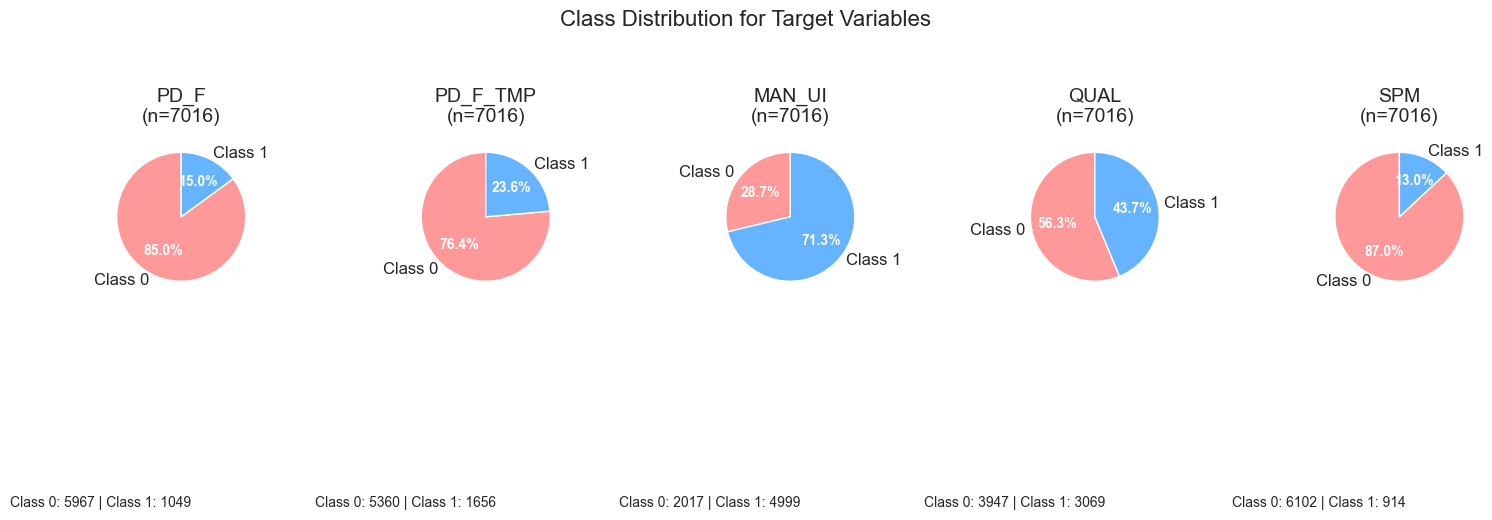


2. Comprehensive Performance Metrics Dashboard


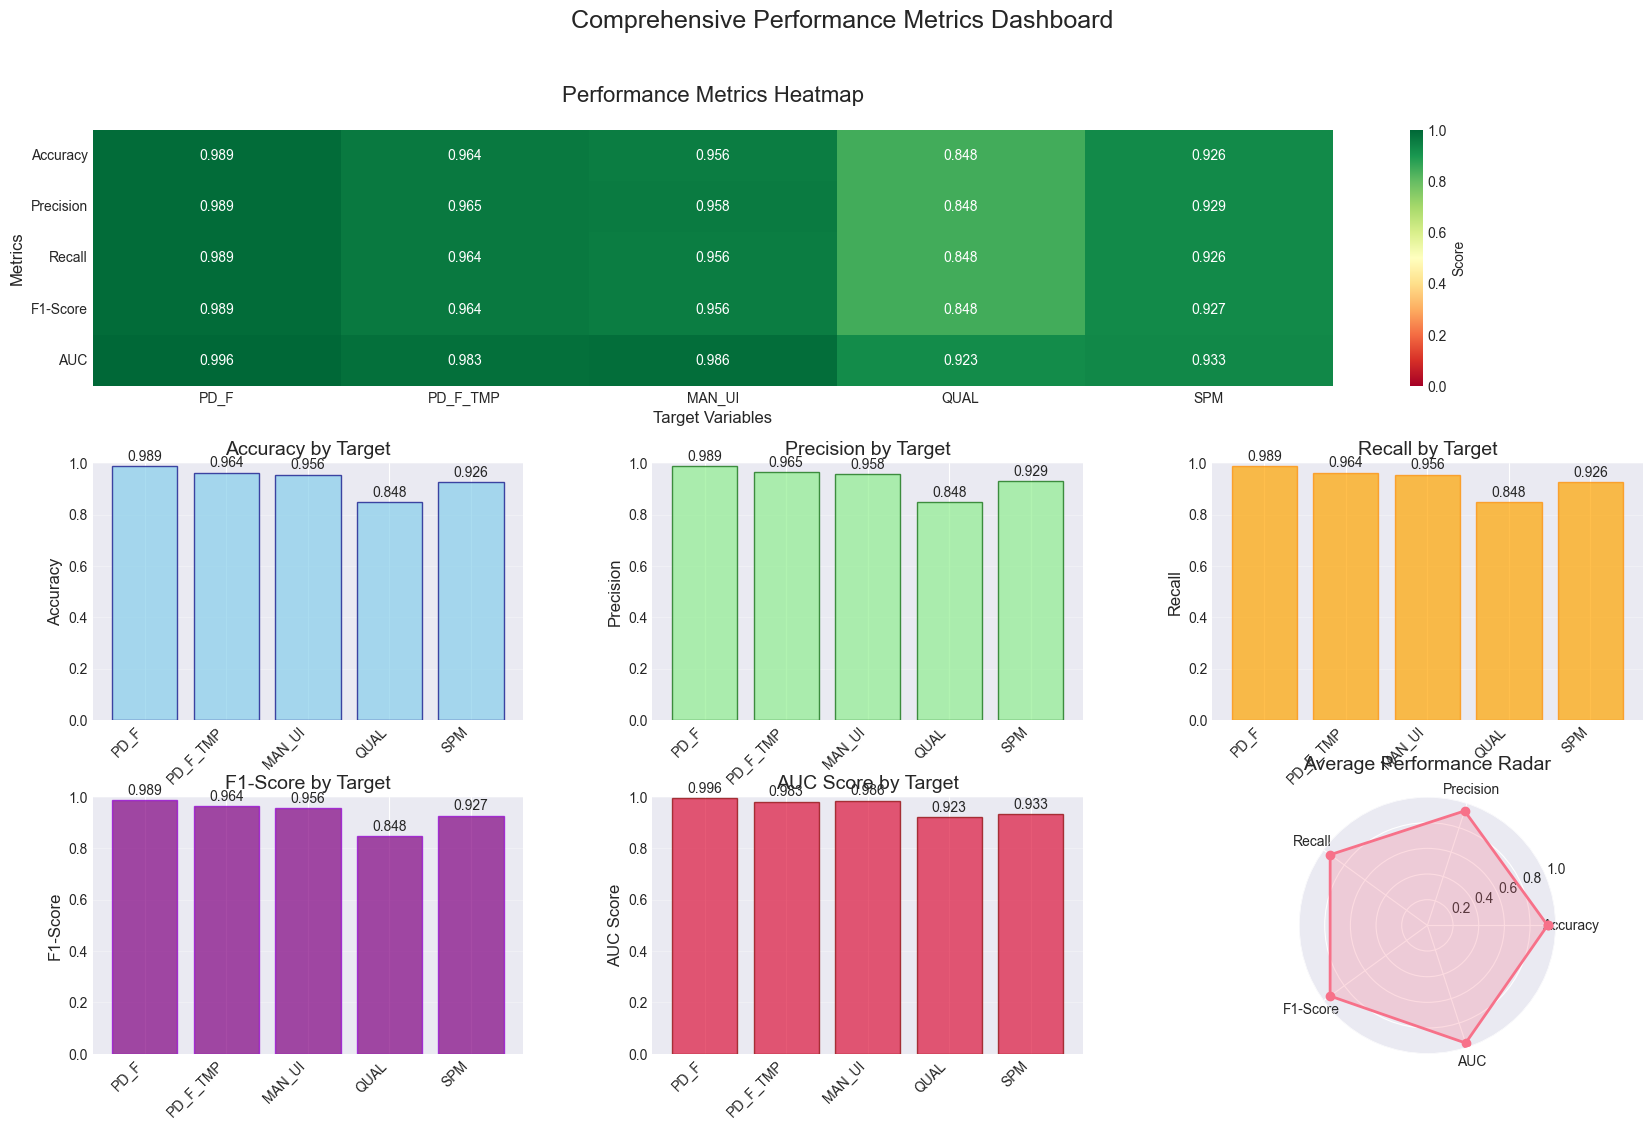


3. Enhanced Confusion Matrix Analysis


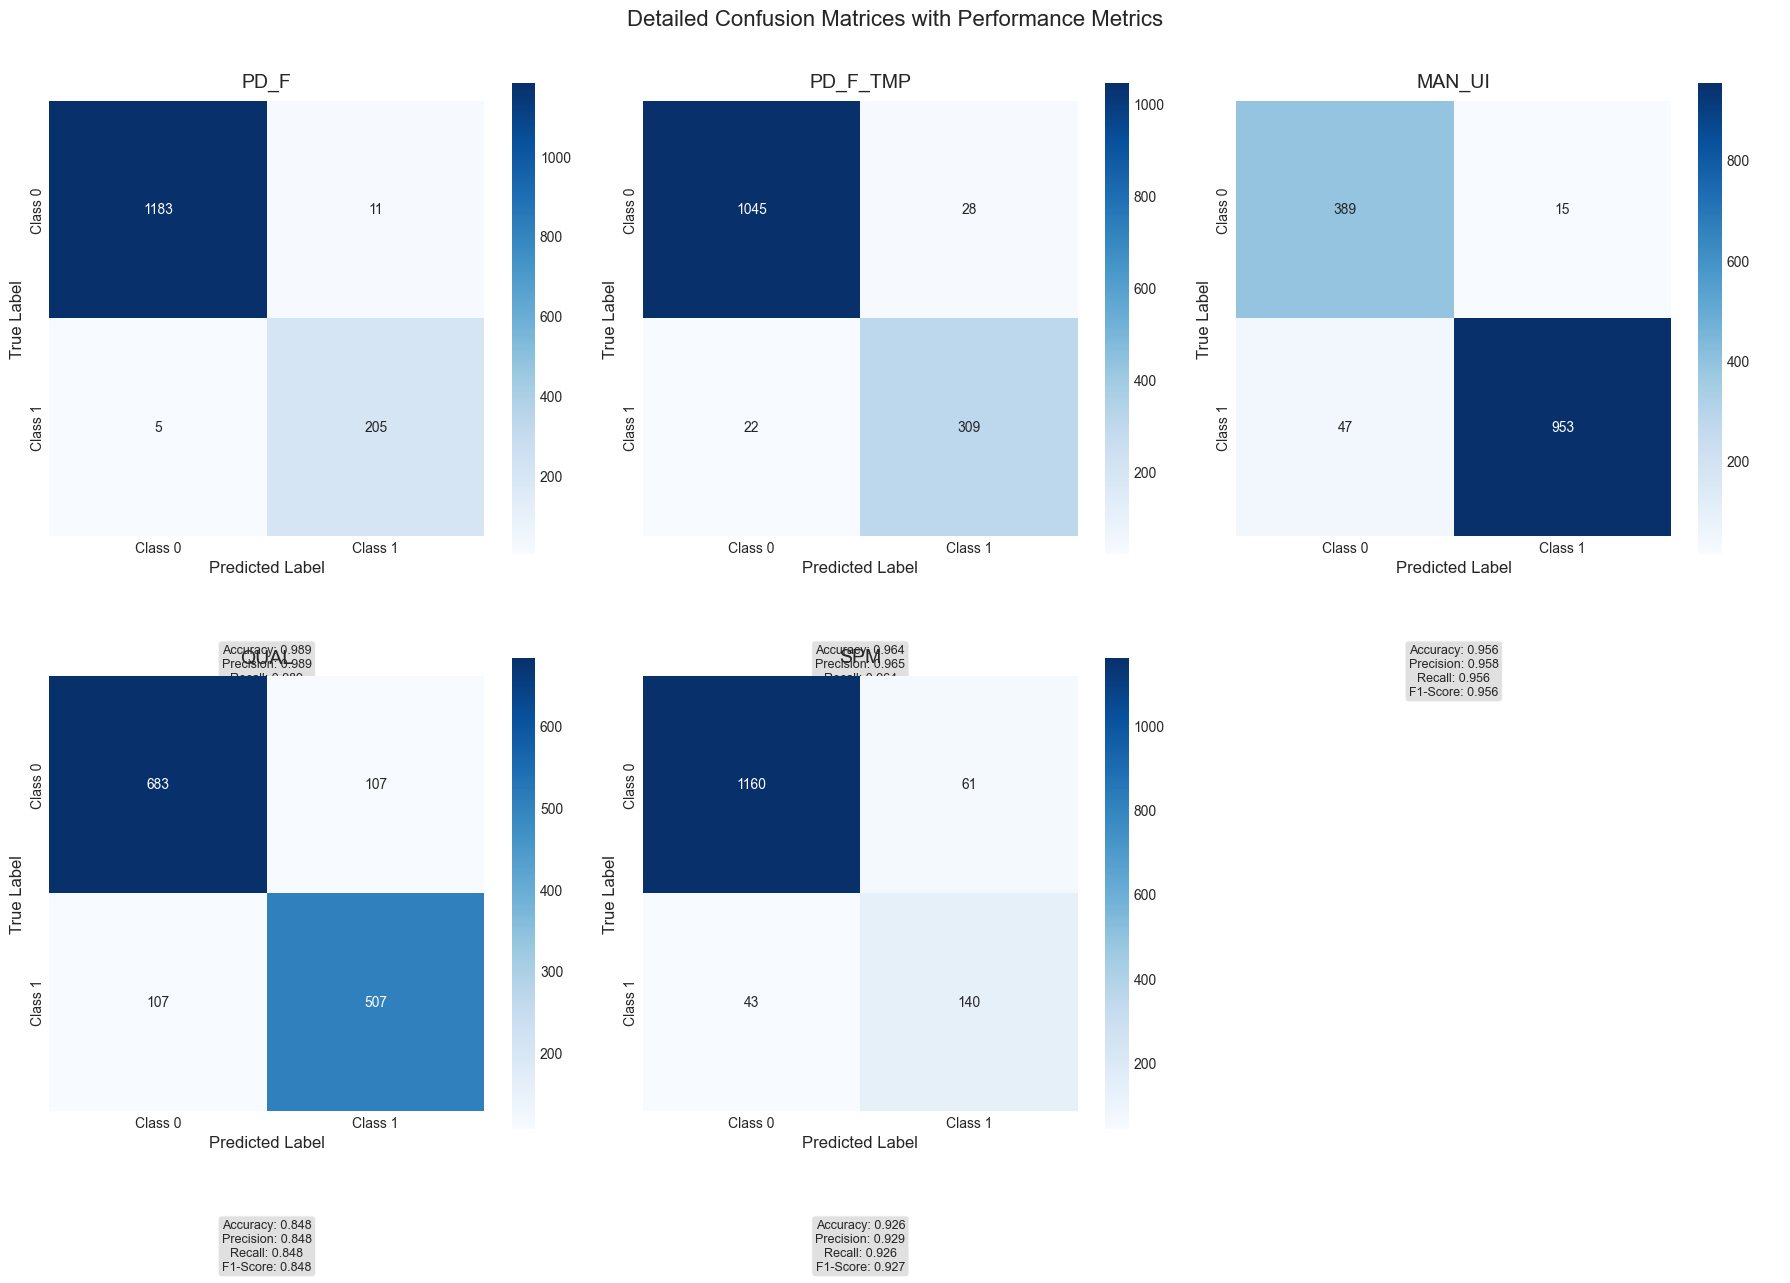


4. ROC Curve Analysis


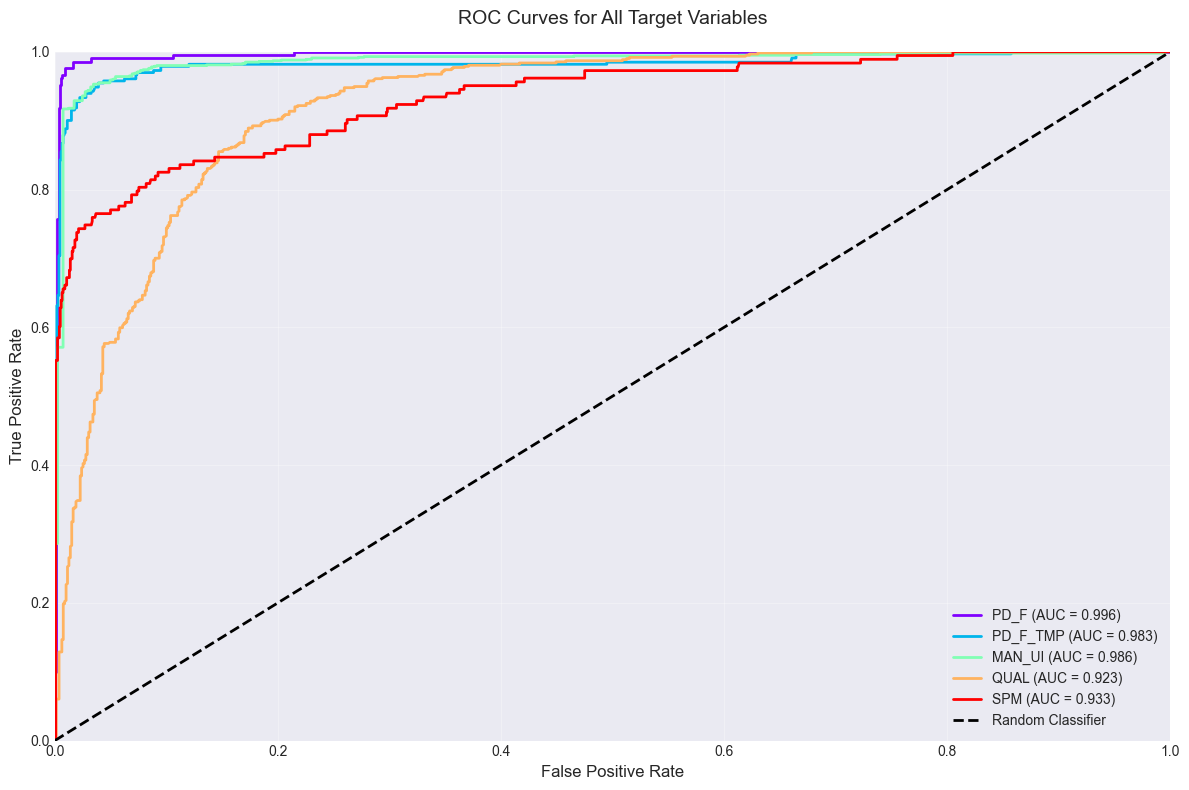


5. Precision-Recall Curve Analysis


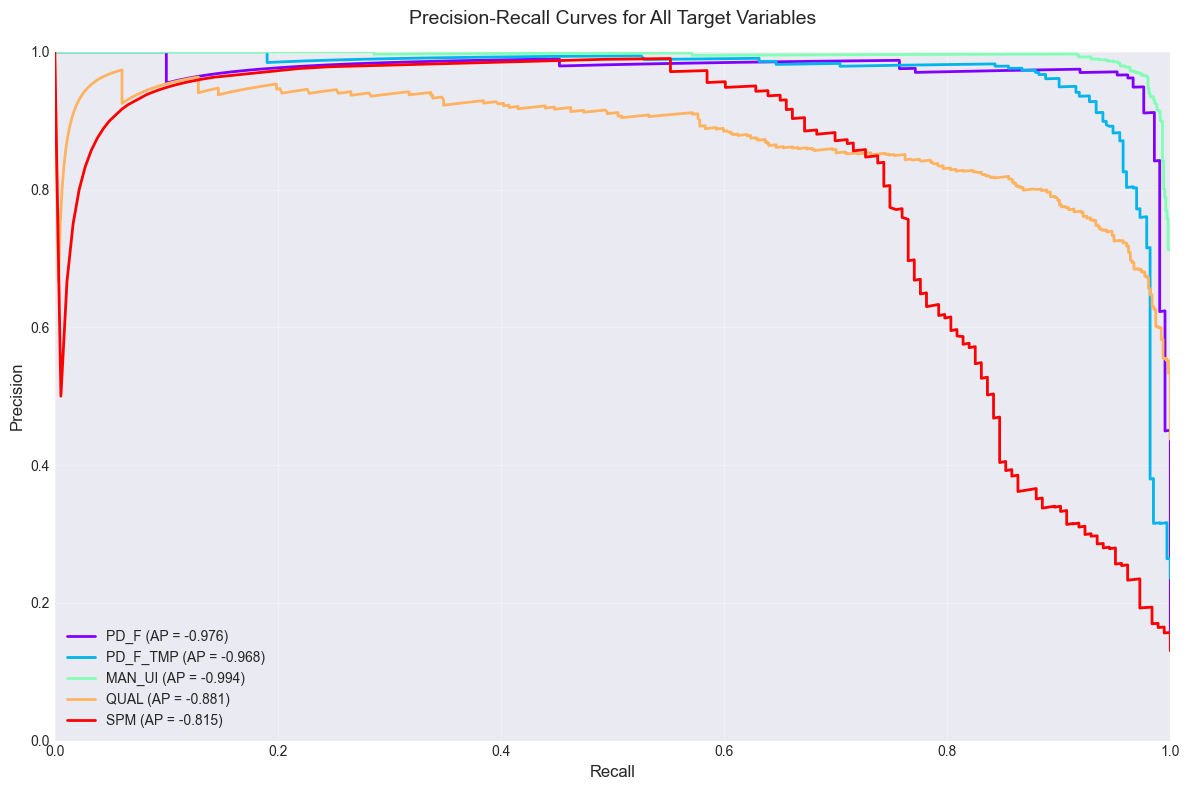


6. Feature Importance Analysis


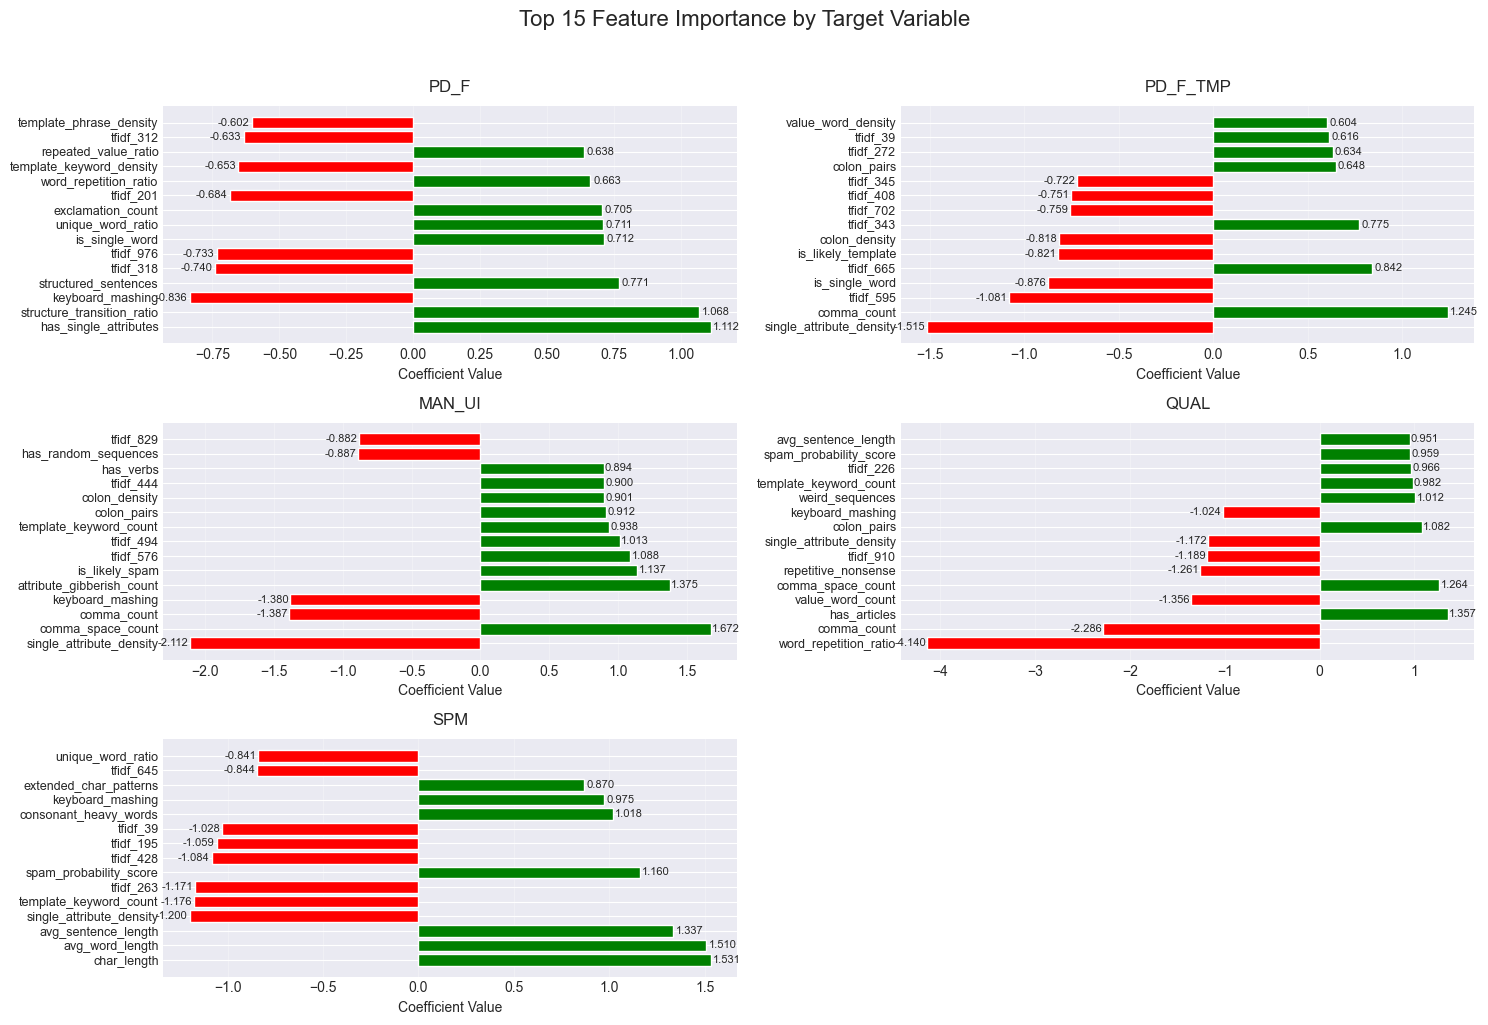


7. Model Comparison Summary


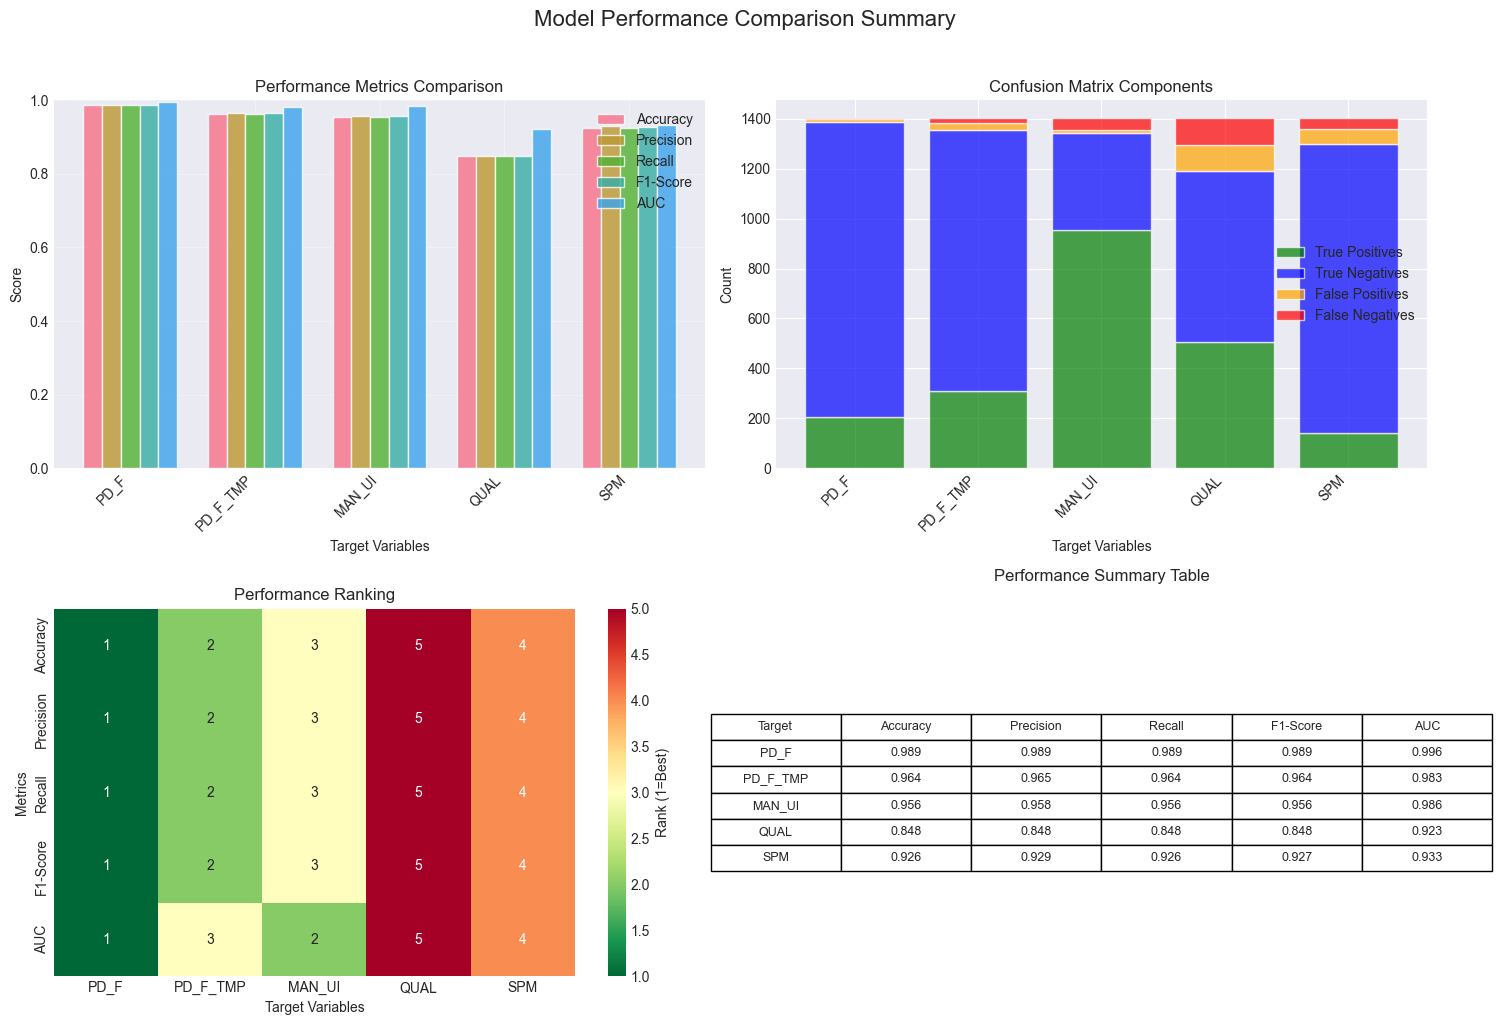


8. Prediction Probability Distributions


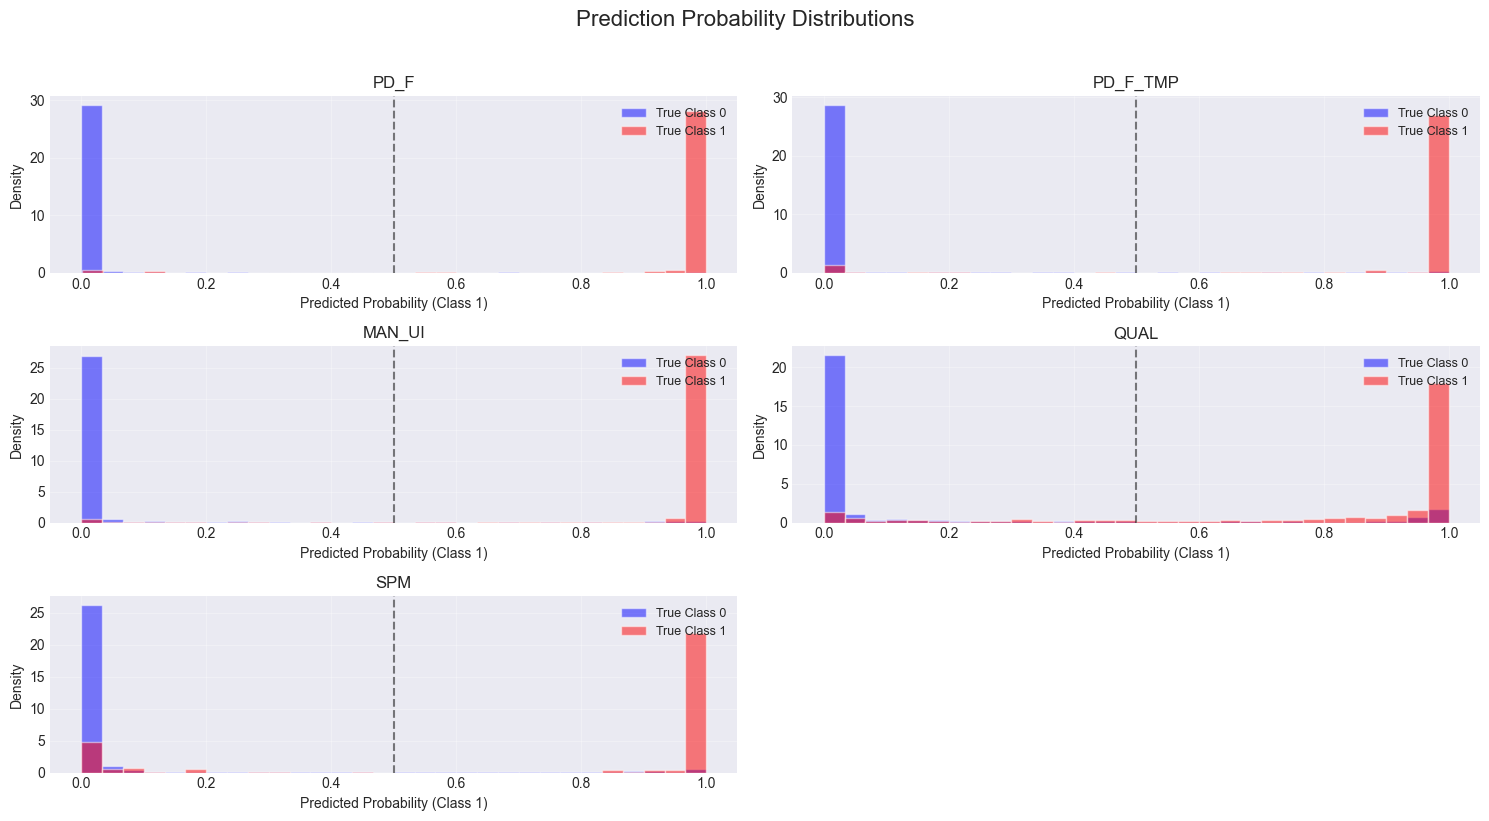


ENHANCED VISUALIZATION COMPLETE!

SUMMARY STATISTICS:
----------------------------------------
Best performing model (by F1-Score): PD_F
Highest accuracy: 0.989
Average AUC across all models: 0.964
Models with AUC > 0.8: 5/5

TRAINING PIPELINE COMPLETED!

Trained models: ['PD_F', 'PD_F_TMP', 'MAN_UI', 'QUAL', 'SPM']


In [443]:
if __name__ == "__main__":
    # Replace with your actual file path
    file_path = "final_combined.xlsx"

    # Run the complete pipeline
    pipeline_results, metrics_df, summary_df = run_full_pipeline_fixed(file_path)

    # Access trained models
    trained_models = pipeline_results['models']
    print(f"\nTrained models: {list(trained_models.keys())}")

# TESTING

In [444]:
# Save your trained models (run this in your training cell)
import pickle
import re

# Save all the trained components
with open('models.pkl', 'wb') as f:
    pickle.dump(pipeline_results['models'], f)
with open('scalers.pkl', 'wb') as f:
    pickle.dump(pipeline_results['scalers'], f)
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(pipeline_results['tfidf'], f)
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(pipeline_results['feature_names'], f)

print("✓ Models saved successfully!")

✓ Models saved successfully!


In [445]:
def predict_review(review_text, models, scalers, tfidf_vectorizer, feature_names):
    """
    Predict all target variables for a single review

    Args:
        review_text (str): The review text to analyze
        models (dict): Trained models for each target
        scalers (dict): Fitted scalers for each target
        tfidf_vectorizer: Fitted TF-IDF vectorizer
        feature_names (list): List of feature column names

    Returns:
        dict: Predictions for each target
    """

    print("=" * 60)
    print("REVIEW ANALYSIS AND PREDICTION")
    print("=" * 60)

    print(f"Input Review: {review_text}")
    print(f"Review Length: {len(review_text)} characters, {len(review_text.split())} words")

    # Clean the review (minimal cleaning)
    clean_text = re.sub(r'\s+', ' ', str(review_text)).strip()

    # Extract template/spam features
    template_features = extract_template_features(clean_text)
    template_df = pd.DataFrame([template_features])

    # Extract TF-IDF features
    tfidf_features = tfidf_vectorizer.transform([clean_text])
    tfidf_df = pd.DataFrame(tfidf_features.toarray(),
                           columns=[f'tfidf_{i}' for i in range(tfidf_features.shape[1])])

    # Combine features
    final_features = pd.concat([template_df, tfidf_df], axis=1)

    # Ensure feature alignment
    for col in feature_names:
        if col not in final_features.columns:
            final_features[col] = 0

    final_features = final_features[feature_names]

    print("\n" + "-" * 40)
    print("KEY FEATURE ANALYSIS")
    print("-" * 40)

    # Show interesting features
    interesting_features = [
        'word_count', 'char_length', 'colon_pairs', 'value_word_count',
        'word_repetition_ratio', 'template_phrase_count', 'punct_density',
        'consecutive_char_groups', 'is_very_short', 'attribute_pattern'
    ]

    for feat in interesting_features:
        if feat in template_features:
            print(f"{feat}: {template_features[feat]}")

    # Make predictions
    predictions = {}
    probabilities = {}

    print("\n" + "-" * 40)
    print("PREDICTIONS")
    print("-" * 40)

    target_descriptions = {
        'PD_F': 'Template Detection',
        'PD_F_TMP': 'Template Phrases',
        'MAN_UI': 'Manual UI',
        'QUAL': 'Quality',
        'SPM': 'Spam'
    }

    for target, model in models.items():
        # Scale features
        scaler = scalers[target]
        X_scaled = scaler.transform(final_features)

        # Make prediction
        prediction = model.predict(X_scaled)[0]
        probability = model.predict_proba(X_scaled)[0]

        predictions[target] = prediction
        probabilities[target] = probability

        # Display results
        prob_class_1 = probability[1]
        result = "POSITIVE" if prediction == 1 else "NEGATIVE"
        confidence = max(probability) * 100

        print(f"{target} ({target_descriptions[target]}):")
        print(f"  Prediction: {result} (confidence: {confidence:.1f}%)")
        print(f"  Probability: {prob_class_1:.3f}")
        print()

    return predictions, probabilities, template_features

def preprocess_text_with_expansion(text):
    """Enhanced preprocessing with contraction expansion and spaced contraction handling."""
    if not text or text == "N/A":
        return ""

    # Convert to string in case of non-string input
    text = str(text)

    # Then apply regular preprocessing
    text = text.replace("\n", " ").replace("\t", " ").replace("\r", " ")

    # Remove emojis
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001F900-\U0001F9FF"
        "\U0001FA70-\U0001FAFF"
        "\U00002600-\U000026FF"
        "\U00002700-\U000027BF"
        "]",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub('.', text)

    # Clean Unicode
    text = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', '', text)
    text = re.sub(r'[^\w\s\.\,\!\?\;\:\-\_\(\)\[\]\{\}\"\'\`\~\@\#\$\%\^\&\*\+\=\|\\\/<>]', '', text, flags=re.UNICODE)

    text = re.sub(r'\s+', ' ', text).strip()

    # Punctuation spacing
    text = re.sub(r'([.!?,:;])\s*', r'\1 ', text)
    text = re.sub(r'\s*(["\'])', r' \1', text)
    text = re.sub(r'(["\'])\s*', r'\1 ', text)
    text = re.sub(r'\s*([(\[])', r' \1', text)
    text = re.sub(r'([)\]])\s*', r'\1 ', text)

    # Final cleanup
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def interactive_testing():
    """Interactive function to test reviews"""
    print("=" * 60)
    print("INTERACTIVE REVIEW TESTING")
    print("=" * 60)
    print("NOTE: Make sure you have trained models saved as:")
    print("- models.pkl")
    print("- scalers.pkl")
    print("- tfidf.pkl")
    print("- feature_names.pkl")
    print()

    try:
        # Load saved models (you'll need to save these from your training)
        with open('models.pkl', 'rb') as f:
            models = pickle.load(f)
        with open('scalers.pkl', 'rb') as f:
            scalers = pickle.load(f)
        with open('tfidf.pkl', 'rb') as f:
            tfidf = pickle.load(f)
        with open('feature_names.pkl', 'rb') as f:
            feature_names = pickle.load(f)

        print("✓ Models loaded successfully!")

    except FileNotFoundError as e:
        print(f"❌ Error loading models: {e}")
        print("Please save your trained models first.")
        return

    while True:
        print("\n" + "=" * 60)
        review = input("Enter a review to test (or 'quit' to exit): ")

        if review.lower() in ['quit', 'exit', 'q']:
            print("Goodbye!")
            break

        if not review.strip():
            print("Please enter a non-empty review.")
            continue

        try:
            preprocessed_text = preprocess_text_with_expansion(review)
            print("Preprocessed text: " + preprocessed_text)

            predictions, probabilities, features = predict_review(
                preprocessed_text, models, scalers, tfidf, feature_names
            )

        except Exception as e:
            print(f"❌ Error making prediction: {e}")
            continue

In [446]:
def predict_review_fixed(review_text, models, scalers, tfidf_vectorizer, feature_names):
    """
    Fixed prediction function for your current setup
    """
    print("=" * 60)
    print("REVIEW ANALYSIS AND PREDICTION")
    print("=" * 60)

    print(f"Input Review: {review_text}")
    print(f"Review Length: {len(review_text)} characters, {len(review_text.split())} words")

    # Clean the review (minimal cleaning)
    clean_text = re.sub(r'\s+', ' ', str(review_text)).strip()

    # Extract template/spam features
    template_features = extract_template_features(clean_text)
    template_df = pd.DataFrame([template_features])

    # Extract TF-IDF features
    tfidf_features = tfidf_vectorizer.transform([clean_text])
    tfidf_df = pd.DataFrame(tfidf_features.toarray(),
                           columns=[f'tfidf_{i}' for i in range(tfidf_features.shape[1])])

    # Combine features
    final_features = pd.concat([template_df, tfidf_df], axis=1)

    # FIXED: Ensure feature alignment by building from scratch
    aligned_features = pd.DataFrame()
    for col in feature_names:
        if col in final_features.columns:
            aligned_features[col] = final_features[col]
        else:
            aligned_features[col] = 0

    print("\n" + "-" * 40)
    print("KEY FEATURE ANALYSIS")
    print("-" * 40)

    # Show interesting features
    interesting_features = [
        'word_count', 'char_length', 'colon_pairs', 'value_word_count',
        'word_repetition_ratio', 'template_phrase_count', 'punct_density',
        'consecutive_char_groups', 'is_very_short', 'attribute_pattern'
    ]

    for feat in interesting_features:
        if feat in template_features:
            print(f"{feat}: {template_features[feat]}")

    # Make predictions
    predictions = {}
    probabilities = {}

    print("\n" + "-" * 40)
    print("PREDICTIONS")
    print("-" * 40)

    target_descriptions = {
        'PD_F': 'Template Detection',
        'PD_F_TMP': 'Template Phrases',
        'MAN_UI': 'Manual UI',
        'QUAL': 'Quality',
        'SPM': 'Spam'
    }

    for target, model in models.items():
        # Scale features
        scaler = scalers[target]
        X_scaled = scaler.transform(aligned_features)

        # Make prediction
        prediction = model.predict(X_scaled)[0]
        probability = model.predict_proba(X_scaled)[0]

        predictions[target] = prediction
        probabilities[target] = probability

        # Display results
        prob_class_1 = probability[1]
        result = "POSITIVE" if prediction == 1 else "NEGATIVE"
        confidence = max(probability) * 100

        print(f"{target} ({target_descriptions[target]}): {result} ({confidence:.1f}%)")
        print(f"  Probability: {prob_class_1:.3f}")

    return predictions, probabilities, template_features

In [447]:
# Or directly run:
interactive_testing()

INTERACTIVE REVIEW TESTING
NOTE: Make sure you have trained models saved as:
- models.pkl
- scalers.pkl
- tfidf.pkl
- feature_names.pkl

✓ Models loaded successfully!



KeyboardInterrupt: Interrupted by user